## Assignment 2: Recurrent Neural Networks and NLP

Sentiment classification on IMDb using Vanilla RNN, LSTM, and Bidirectional LSTM

### Part 0: Setup & Data Preprocessing

In [1]:
# Reproducibility seeds — set before any imports that use randomness
import random, torch, numpy as np
random.seed(42)
torch.manual_seed(42)
np.random.seed(42)
print("Seeds set.")


Seeds set.


### 0.1: Load the IMDb Dataset

In [2]:
from datasets import load_dataset

# 25,000 train / 25,000 test reviews; label 0=negative, 1=positive
dataset    = load_dataset("imdb")
train_data = dataset["train"]
test_data  = dataset["test"]

print(train_data[0]["text"][:200])
print("Label:", train_data[0]["label"])

c:\Users\kiera\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev
Label: 0


### 0.2. Tokenisation & Vocabulary

In [3]:
import re
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# ── Preprocessing constants ────────────────────────────────────────────────────
VOCAB_SIZE = 20_000   # keep only the 20,000 most frequent words
MAX_LEN    = 500      # truncate reviews longer than this
PAD_IDX    = 0        # padding token index
UNK_IDX    = 1        # unknown token index

def tokenize(text):
    """Lowercase and extract alphabetic tokens (letters + apostrophes)."""
    return re.findall(r"\b[a-z']+\b", text.lower())

# Build vocabulary from the training set only — avoids test leakage
counter = Counter()
for ex in train_data:
    counter.update(tokenize(ex["text"]))

# Reserve 0=<pad> and 1=<unk>; assign remaining indices to top words
vocab = {"<pad>": PAD_IDX, "<unk>": UNK_IDX}
vocab.update({w: i + 2 for i, (w, _) in enumerate(counter.most_common(VOCAB_SIZE))})
print(f"Vocabulary size (incl. special tokens): {len(vocab)}")

def encode(text):
    """Convert a raw string into a list of token indices, truncated to MAX_LEN."""
    tokens = tokenize(text)[:MAX_LEN]
    return [vocab.get(t, UNK_IDX) for t in tokens]


class IMDbDataset(Dataset):
    """Pre-encodes all reviews at construction time for fast DataLoader iteration."""
    def __init__(self, split):
        self.samples = [
            (
                torch.tensor(encode(ex["text"]), dtype=torch.long),
                torch.tensor(ex["label"],        dtype=torch.long)
            )
            for ex in dataset[split]
        ]
    def __len__(self):      
        return len(self.samples)
    def __getitem__(self, i): 
        return self.samples[i]


def collate(batch):
    """Dynamically pad each mini-batch to the length of its longest sequence."""
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(t) for t in texts], dtype=torch.long)  # true lengths before padding
    texts   = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    return texts, torch.stack(labels), lengths


Vocabulary size (incl. special tokens): 20002


In [4]:
# Build datasets and loaders
print("Encoding all reviews...")
train_dataset = IMDbDataset("train")
test_dataset  = IMDbDataset("test")

# batch_size=64 balances GPU memory and gradient noise
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  collate_fn=collate)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, collate_fn=collate)
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")


Encoding all reviews...
Train batches: 391 | Test batches: 391


## Part 1. Vanilla RNN Sentiment Classifier
### Task 1.1. Define Basic RNN Model and Training Loop

In [5]:
import torch.nn as nn, time, matplotlib.pyplot as plt

class RNNClassifier(nn.Module):
    """
    Vanilla RNN: Embedding -> single-layer RNN -> Dropout -> Linear.
    Uses only the final hidden state for binary sentiment classification.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_classes, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.rnn       = nn.RNN(embed_dim, hidden_dim, batch_first=True, nonlinearity="tanh")
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        embedded    = self.dropout(self.embedding(x))  # (batch, seq, embed_dim)
        _, hidden   = self.rnn(embedded)               # hidden: (1, batch, hidden_dim)
        hidden      = hidden.squeeze(0)                # remove layer dim -> (batch, hidden_dim)
        return self.fc(self.dropout(hidden))


def train_model(model, loader, optimizer, criterion, device):
    """One full training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for texts, labels, _ in loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(texts)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # prevent exploding gradients
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += labels.size(0)
    return total_loss / n, correct / n


def evaluate_model(model, loader, criterion, device):
    """Evaluation pass with no gradient computation. Returns (avg_loss, accuracy)."""
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for texts, labels, _ in loader:
            texts, labels = texts.to(device), labels.to(device)
            logits = model(texts)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            n          += labels.size(0)
    return total_loss / n, correct / n


def run_training(model, train_loader, test_loader, n_epochs=5, lr=1e-3):
    """Full training run. Returns a history dict with per-epoch metrics."""
    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model     = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history   = {"train_loss": [], "train_acc": [],
                 "test_loss":  [], "test_acc":  [], "epoch_time": []}
    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_model(model, train_loader, optimizer, criterion, device)
        te_loss, te_acc = evaluate_model(model, test_loader, criterion, device)
        elapsed = time.time() - t0
        history["train_loss"].append(tr_loss);  history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss);   history["test_acc"].append(te_acc)
        history["epoch_time"].append(elapsed)
        print(f"Epoch {epoch}/{n_epochs} | Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}"
              f" | Test Loss: {te_loss:.4f}  Acc: {te_acc:.4f} | Time: {elapsed:.1f}s")
    return history


# Instantiate the vanilla RNN
model_rnn    = RNNClassifier(vocab_size=len(vocab), embed_dim=128, hidden_dim=256, n_classes=2)
n_params_rnn = sum(p.numel() for p in model_rnn.parameters() if p.requires_grad)
print(model_rnn)
print(f"Trainable parameters: {n_params_rnn:,}")


RNNClassifier(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (rnn): RNN(128, 256, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)
Trainable parameters: 2,659,586


In [6]:
print("=== Training Vanilla RNN ===")
history_rnn = run_training(model_rnn, train_loader, test_loader, n_epochs=5, lr=1e-3)
print(f"\nFinal Test Accuracy (RNN): {history_rnn['test_acc'][-1]:.4f}")

=== Training Vanilla RNN ===
Epoch 1/5 | Train Loss: 0.6980  Acc: 0.5016 | Test Loss: 0.6952  Acc: 0.4964 | Time: 4.0s
Epoch 2/5 | Train Loss: 0.7094  Acc: 0.5027 | Test Loss: 0.6970  Acc: 0.5002 | Time: 3.6s
Epoch 3/5 | Train Loss: 0.7069  Acc: 0.5050 | Test Loss: 0.6952  Acc: 0.5007 | Time: 3.6s
Epoch 4/5 | Train Loss: 0.7075  Acc: 0.5012 | Test Loss: 0.6944  Acc: 0.5006 | Time: 3.5s
Epoch 5/5 | Train Loss: 0.7041  Acc: 0.5034 | Test Loss: 0.7311  Acc: 0.5012 | Time: 3.5s

Final Test Accuracy (RNN): 0.5012


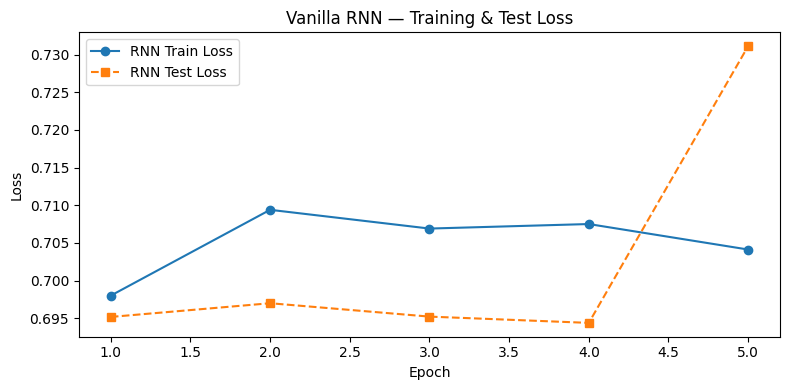

In [7]:
# Plot training and test loss curves for the vanilla RNN
epochs = range(1, 6)
plt.figure(figsize=(8, 4))
plt.plot(epochs, history_rnn["train_loss"], marker="o", label="RNN Train Loss")
plt.plot(epochs, history_rnn["test_loss"],  marker="s", linestyle="--", label="RNN Test Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Vanilla RNN — Training & Test Loss")
plt.legend(); plt.tight_layout()
plt.savefig("rnn_loss.png", dpi=150); plt.show()

## Part 2. LSTM Sentiment Classifier
### Task 2.1. Define LSTM Model

In [8]:
class LSTMClassifier(nn.Module):
    """
    2-layer stacked LSTM: Embedding -> LSTM -> Dropout -> Linear.
    The gating mechanism (forget/input/output gates) mitigates vanishing gradients.
    nn.LSTM returns (output, (hidden, cell)) — we use only the final hidden state.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_classes, n_layers=2, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                                 batch_first=True, dropout=dropout if n_layers > 1 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        embedded       = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)   # hidden: (n_layers, batch, hidden_dim)
        hidden         = hidden[-1]            # take last-layer hidden state
        return self.fc(self.dropout(hidden))


model_lstm    = LSTMClassifier(vocab_size=len(vocab), embed_dim=128,
                                hidden_dim=256, n_classes=2, n_layers=2)
n_params_lstm = sum(p.numel() for p in model_lstm.parameters() if p.requires_grad)
print(model_lstm)
print(f"Trainable parameters: {n_params_lstm:,}")

LSTMClassifier(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)
Trainable parameters: 3,482,370


### Task 2.2. Train the LSTM

In [9]:
print("=== Training LSTM ===")
history_lstm = run_training(model_lstm, train_loader, test_loader, n_epochs=5, lr=1e-3)
print(f"\nFinal Test Accuracy (LSTM): {history_lstm['test_acc'][-1]:.4f}")

=== Training LSTM ===
Epoch 1/5 | Train Loss: 0.6935  Acc: 0.5072 | Test Loss: 0.6932  Acc: 0.4989 | Time: 24.3s
Epoch 2/5 | Train Loss: 0.6926  Acc: 0.5015 | Test Loss: 0.6932  Acc: 0.4999 | Time: 24.1s
Epoch 3/5 | Train Loss: 0.6905  Acc: 0.5141 | Test Loss: 0.6954  Acc: 0.5044 | Time: 24.3s
Epoch 4/5 | Train Loss: 0.6974  Acc: 0.5043 | Test Loss: 0.6939  Acc: 0.5000 | Time: 26.1s
Epoch 5/5 | Train Loss: 0.6939  Acc: 0.5014 | Test Loss: 0.6934  Acc: 0.5000 | Time: 26.4s

Final Test Accuracy (LSTM): 0.5000


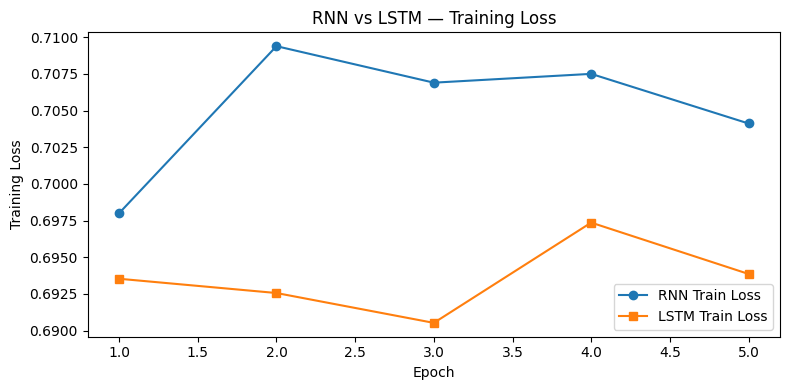

In [10]:
# Comparative loss plot: RNN vs LSTM
plt.figure(figsize=(8, 4))
plt.plot(epochs, history_rnn["train_loss"],  marker="o", label="RNN Train Loss")
plt.plot(epochs, history_lstm["train_loss"], marker="s", label="LSTM Train Loss")
plt.xlabel("Epoch"); plt.ylabel("Training Loss"); plt.title("RNN vs LSTM — Training Loss")
plt.legend(); plt.tight_layout()
plt.savefig("rnn_vs_lstm_loss.png", dpi=150); plt.show()

## Part 3. Bidirectional LSTM
### Task 3.1. Define BRNN (B-LSTM)

In [11]:
class BRNNClassifier(nn.Module):
    """
    Bidirectional LSTM: runs one LSTM left-to-right and one right-to-left,
    then concatenates their final hidden states giving access to past and future context.
    Key changes vs LSTMClassifier:
      - bidirectional=True  -> hidden shape: (n_layers*2, batch, hidden_dim)
      - Linear input doubled -> 2 * hidden_dim  (one vector per direction)
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_classes, n_layers=2, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                                 batch_first=True, bidirectional=True,  # key change
                                 dropout=dropout if n_layers > 1 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, n_classes)  # doubled input size

    def forward(self, x):
        embedded       = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        # hidden[-2]: forward direction of last layer  | hidden[-1]: backward direction
        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)  # (batch, 2*hidden_dim)
        return self.fc(self.dropout(hidden_cat))


model_brnn    = BRNNClassifier(vocab_size=len(vocab), embed_dim=128,
                                hidden_dim=256, n_classes=2, n_layers=2)
n_params_brnn = sum(p.numel() for p in model_brnn.parameters() if p.requires_grad)
print(model_brnn)
print(f"Trainable parameters: {n_params_brnn:,}")

BRNNClassifier(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=2, bias=True)
)
Trainable parameters: 4,928,770


### Task 3.2. Train the BRNN

In [12]:
print("=== Training Bidirectional LSTM (BRNN) ===")
history_brnn = run_training(model_brnn, train_loader, test_loader, n_epochs=5, lr=1e-3)
print(f"\nFinal Test Accuracy (BRNN): {history_brnn['test_acc'][-1]:.4f}")


=== Training Bidirectional LSTM (BRNN) ===
Epoch 1/5 | Train Loss: 0.6731  Acc: 0.5798 | Test Loss: 0.6229  Acc: 0.6578 | Time: 50.5s
Epoch 2/5 | Train Loss: 0.6143  Acc: 0.6706 | Test Loss: 0.6152  Acc: 0.6641 | Time: 49.5s
Epoch 3/5 | Train Loss: 0.5612  Acc: 0.7244 | Test Loss: 0.5070  Acc: 0.7839 | Time: 55.9s
Epoch 4/5 | Train Loss: 0.4883  Acc: 0.7714 | Test Loss: 0.4129  Acc: 0.8257 | Time: 58.2s
Epoch 5/5 | Train Loss: 0.4014  Acc: 0.8276 | Test Loss: 0.3748  Acc: 0.8494 | Time: 60.5s

Final Test Accuracy (BRNN): 0.8494


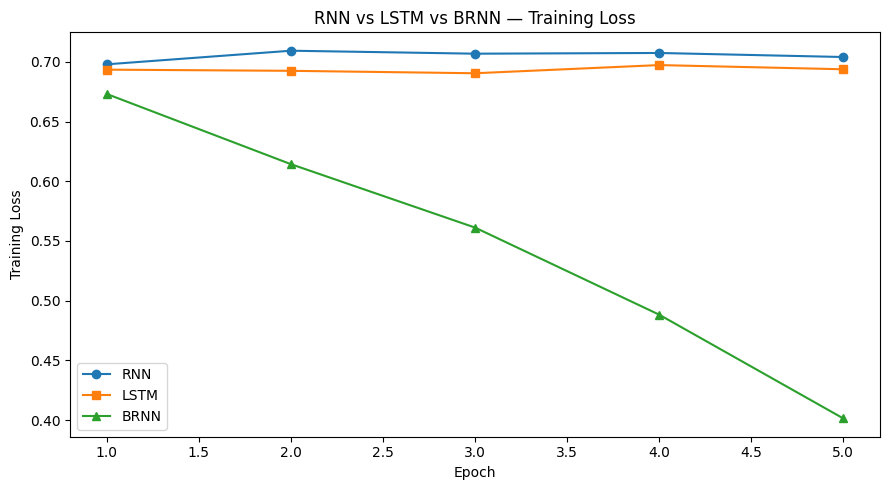

In [13]:
# Three-way comparative loss plot
plt.figure(figsize=(9, 5))
plt.plot(epochs, history_rnn["train_loss"],  marker="o", label="RNN")
plt.plot(epochs, history_lstm["train_loss"], marker="s", label="LSTM")
plt.plot(epochs, history_brnn["train_loss"], marker="^", label="BRNN")
plt.xlabel("Epoch"); plt.ylabel("Training Loss"); plt.title("RNN vs LSTM vs BRNN — Training Loss")
plt.legend(); plt.tight_layout()
plt.savefig("all_models_loss.png", dpi=150); plt.show()

## Part 4. Experiments, Analysis and Report
### Task 4.1. Head-to-Head Summary Table

In [14]:
# Compute average epoch time across all 5 epochs for each model
avg_time_rnn  = sum(history_rnn["epoch_time"])  / len(history_rnn["epoch_time"])
avg_time_lstm = sum(history_lstm["epoch_time"]) / len(history_lstm["epoch_time"])
avg_time_brnn = sum(history_brnn["epoch_time"]) / len(history_brnn["epoch_time"])

print(f"{'Model':<15} {'Test Acc':>10} {'Parameters':>12} {'Avg Epoch (s)':>15}")
print("-" * 55)
print(f"{'Vanilla RNN':<15} {history_rnn['test_acc'][-1]:>10.4f} {n_params_rnn:>12,} {avg_time_rnn:>15.1f}")
print(f"{'LSTM':<15} {history_lstm['test_acc'][-1]:>10.4f} {n_params_lstm:>12,} {avg_time_lstm:>15.1f}")
print(f"{'BRNN':<15} {history_brnn['test_acc'][-1]:>10.4f} {n_params_brnn:>12,} {avg_time_brnn:>15.1f}")

Model             Test Acc   Parameters   Avg Epoch (s)
-------------------------------------------------------
Vanilla RNN         0.5012    2,659,586             3.6
LSTM                0.5000    3,482,370            25.0
BRNN                0.8494    4,928,770            54.9


### Task 4.2. Live Prediction Function

In [15]:
def predict_sentiment(text, model, vocab, device):
    """
    Predict the sentiment of a raw English string.
    Returns: (label, confidence) where label is 'Positive' or 'Negative'
             and confidence is the model's predicted class probability.
    """
    model.eval()  # disable dropout for deterministic inference
    indices = encode(text)                                  # tokenise and encode
    tensor  = torch.tensor(indices, dtype=torch.long)      # convert to tensor
    tensor  = tensor.unsqueeze(0).to(device)               # add batch dimension
    with torch.no_grad():
        logits = model(tensor)                 # forward pass
        probs  = torch.softmax(logits, dim=1)  # convert logits to probabilities
    pred_idx   = probs.argmax(dim=1).item()    # 0=Negative, 1=Positive
    confidence = probs[0, pred_idx].item()     # probability of the predicted class
    label      = "Positive" if pred_idx == 1 else "Negative"
    return label, confidence


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Four test reviews: 2 obviously positive, 2 ambiguous
test_reviews = [
    ("This movie was absolutely fantastic! The performances were brilliant and "
     "the story was deeply moving. One of the best films I have seen in years.",
     "Obviously Positive"),
    ("A masterpiece of cinema. Every scene is beautifully crafted and the acting "
     "is superb. I laughed, I cried, I was completely captivated.",
     "Obviously Positive"),
    ("The film had its moments but felt overly long. Some scenes dragged while "
     "others were genuinely compelling. Not bad, but not particularly memorable.",
     "Ambiguous"),
    ("I am not sure what to make of this. It starts off slow, almost to the point "
     "of boredom, yet the final act was surprisingly touching. Mixed feelings overall.",
     "Ambiguous"),
]

print("Predictions using BRNN (best model):")
print("-" * 70)
for review, category in test_reviews:
    label, conf = predict_sentiment(review, model_brnn, vocab, device)
    print(f"[{category}]")
    print(f"  Review   : {review[:80]}...")
    print(f"  Predicted: {label}  (confidence: {conf:.3f})")
    print()


Predictions using BRNN (best model):
----------------------------------------------------------------------
[Obviously Positive]
  Review   : This movie was absolutely fantastic! The performances were brilliant and the sto...
  Predicted: Positive  (confidence: 0.972)

[Obviously Positive]
  Review   : A masterpiece of cinema. Every scene is beautifully crafted and the acting is su...
  Predicted: Positive  (confidence: 0.971)

[Ambiguous]
  Review   : The film had its moments but felt overly long. Some scenes dragged while others ...
  Predicted: Negative  (confidence: 0.801)

[Ambiguous]
  Review   : I am not sure what to make of this. It starts off slow, almost to the point of b...
  Predicted: Positive  (confidence: 0.819)



### Task 4.3. Error Analysis

In [18]:
# Collect all predictions and true labels from the test set using the best model (BRNN)
model_brnn.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

all_preds, all_labels, all_texts = [], [], []
with torch.no_grad():
    for texts, labels, _ in test_loader:
        logits = model_brnn(texts.to(device))
        preds  = logits.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)
        all_texts.append(texts)

# Concatenate all batches
all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
# Stack into a 2D tensor (n_samples, seq_len) instead of cat
all_texts  = torch.nn.utils.rnn.pad_sequence(
    [t for batch in all_texts for t in batch],
    batch_first=True, padding_value=PAD_IDX
)

idx_to_word   = {v: k for k, v in vocab.items()}
wrong_indices = torch.where(all_preds != all_labels)[0]
print(f"Total misclassified examples: {len(wrong_indices)}")

label_map = {0: "Negative", 1: "Positive"}

for rank, idx in enumerate(wrong_indices[:5], start=1):
    idx       = idx.item()
    token_ids = all_texts[idx].tolist()  # now correctly a list of ints
    words     = [idx_to_word.get(t, "<unk>") for t in token_ids if t != PAD_IDX][:100]
    print(f"--- Misclassification {rank} ---")
    print(f"First 100 tokens : {' '.join(words)}")
    print(f"True label       : {label_map[all_labels[idx].item()]}")
    print(f"Predicted label  : {label_map[all_preds[idx].item()]}")
    print()

Total misclassified examples: 3765
--- Misclassification 1 ---
First 100 tokens : first off let me say if you haven't enjoyed a van damme movie since <unk> you probably will not like this movie most of these movies may not have the best plots or best actors but i enjoy these kinds of movies for what they are this movie is much better than any of the movies the other action guys segal and dolph have thought about putting out the past few years van damme is good in the movie the movie is only worth watching to van damme fans it is not as good as wake of death which i
True label       : Negative
Predicted label  : Positive

--- Misclassification 2 ---
First 100 tokens : isaac <unk> has made some of the best western martial arts action movies ever produced in particular us seals cold harvest special forces and undisputed are all action classics you can tell isaac has a real passion for the genre and his films are always eventful creative and sharp affairs with some of the best fight sequen